In [ ]:
/Users/suetake/git-repos/takano_labo/dca/src/model.py

### MNIST 100-sample PCA→MLP
MNIST を OpenML から取得し、ランダムに 100 件を訓練、100 件をテストに取り、PCA(10 次元)で圧縮して `src/model.py` の MLP で精度を確認。

In [1]:
from sklearn.datasets import fetch_openml
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from src.model import ModelRunner

# 乱数シード
SEED = 0

# MNIST をロード（70,000枚: train+test 合体）
mnist = fetch_openml("mnist_784", version=1, as_frame=False)
X = mnist.data.astype(float)
y = mnist.target

# ランダムに 100 件を訓練、100 件をテストにサンプリング（層化）
X_train, X_test, y_train, y_test = train_test_split(
    X, y, train_size=100, test_size=100, stratify=y, random_state=SEED
)

# 標準化 -> PCA(10次元)
scaler = StandardScaler()
X_train_std = scaler.fit_transform(X_train)
X_test_std = scaler.transform(X_test)

pca = PCA(n_components=10, random_state=SEED)
X_train_pca = pca.fit_transform(X_train_std)
X_test_pca = pca.transform(X_test_std)

# model.py の MLP を使用
class _Cfg:
    h_model = "mlp"
    metrics = "accuracy"
    seed = SEED

cfg = _Cfg()
runner = ModelRunner(cfg)
acc = runner.run(X_train_pca, y_train, X_test_pca, y_test)
print(f"Accuracy on 100 test samples: {acc:.4f}")


Accuracy on 100 test samples: 0.5400


In [3]:
import japanize_matplotlib

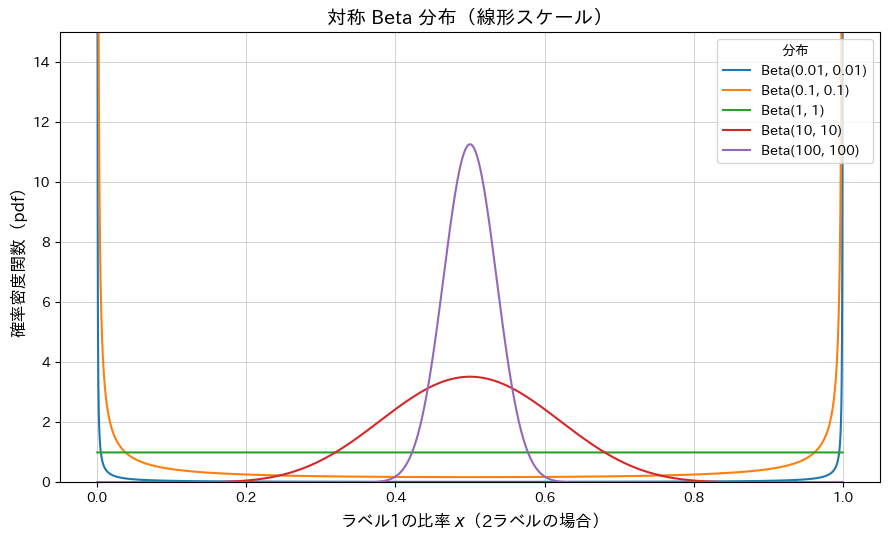

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.special import betaln

# パラメータ
betas = [1e-2, 1e-1, 1, 10, 100]
x = np.linspace(1e-6, 1 - 1e-6, 8000)

# Beta(a,a) の pdf（数値安定化のため log で計算）
def beta_pdf(x, beta):
    return np.exp((beta - 1) * np.log(x) +
                  (beta - 1) * np.log(1 - x) -
                  betaln(beta, beta))

# 描画
plt.figure(figsize=(9, 5.5))
for b in betas:
    plt.plot(x, beta_pdf(x, b), label=f"Beta({b:g}, {b:g})")

# 日本語ラベル
plt.title("対称 Beta 分布（線形スケール）", fontsize=14)
plt.xlabel("ラベル1の比率 $x$（2ラベルの場合）", fontsize=12)
plt.ylabel("確率密度関数（pdf）", fontsize=12)

plt.ylim(0, 15)
plt.legend(title="分布", fontsize=10)
plt.grid(True, linewidth=0.4)

plt.tight_layout()
plt.show()



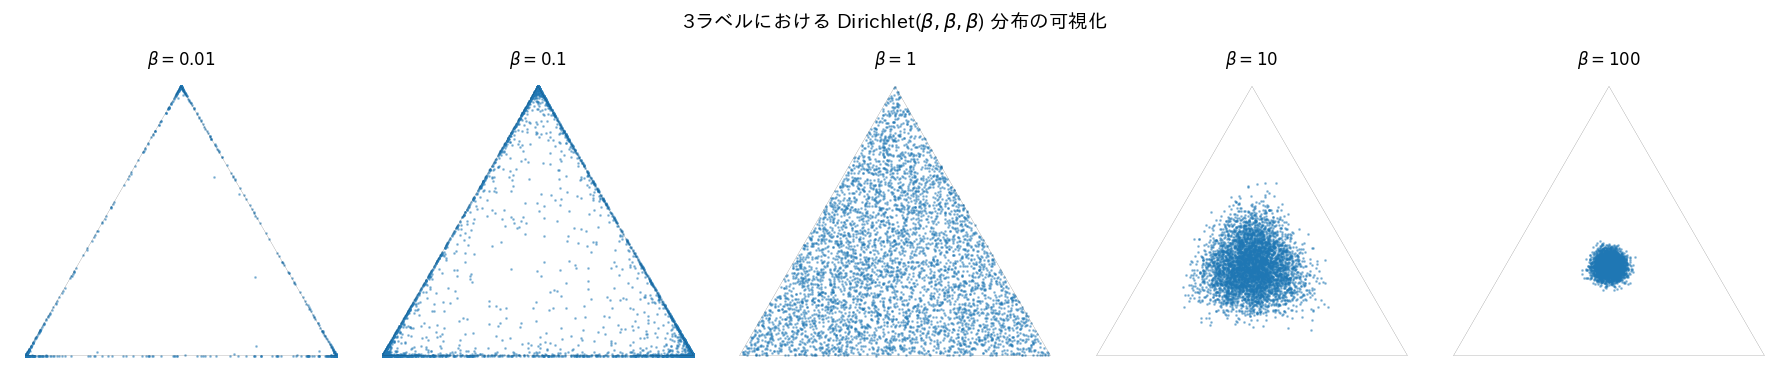

In [8]:
import numpy as np
import matplotlib.pyplot as plt

# パラメータ
betas = [1e-2, 1e-1, 1, 10, 100]
L = 3
n_samples = 5000

# 正三角形（3ラベル単体）の頂点
V = np.array([
    [0.0, 0.0],                 # ラベル1
    [1.0, 0.0],                 # ラベル2
    [0.5, np.sqrt(3) / 2],      # ラベル3
])

def simplex_projection(p):
    """3次元Dirichletサンプルを2次元単体へ射影"""
    return p @ V

fig, axes = plt.subplots(1, len(betas), figsize=(18, 4),
                         sharex=True, sharey=True)

for ax, beta in zip(axes, betas):
    samples = np.random.dirichlet([beta] * L, size=n_samples)
    xy = simplex_projection(samples)

    ax.scatter(xy[:, 0], xy[:, 1], s=1, alpha=0.4)
    ax.set_title(rf"$\beta={beta:g}$")
    ax.set_aspect("equal")
    ax.axis("off")

    # 単体（正三角形）の枠線
    tri = np.vstack([V, V[0]])
    ax.plot(tri[:, 0], tri[:, 1], color="black", linewidth=0.1)

fig.suptitle("3ラベルにおける Dirichlet($\\beta,\\beta,\\beta$) 分布の可視化",
             fontsize=14)
plt.tight_layout()
plt.show()



In [9]:
import pandas as pd
import numpy as np
from pathlib import Path

# =========================
# 設定
# =========================
DATASET_MAP = {
    "MNIST": "MNIST",
    "FashionMNIST": "Fashion-MNIST",
}

COND_MAP = {
    "SamespanOrth": "直交-共通列空間",
    "DiffspanOrth": "ランダム直交行列",
}

METHODS = {
    "摂動最小": {
        "I": "acc_Imakura",
        "R": "acc_Imakura_rand",
        "Q": "acc_Imakura_rand_orth",
    },
    "ペアワイズ": {
        "I": "acc_Kawakami",
        "Q": "acc_Kawakami_rand_orth",
    },
    "プロクラステス": {
        "I": "acc_Nosaka",
        "Q": "acc_Nosaka_rand",
    },
}

# =========================
# ユーティリティ
# =========================
def mean_std(series):
    return series.mean() * 100, series.std(ddof=1) * 100


def format_pm(mean, std):
    return f"{mean:.2f}±{std:.2f}"


def format_delta(delta):
    sign = "+" if delta >= 0 else ""
    return f"{sign}{delta:.2f}"


# =========================
# メイン処理
# =========================
def build_dataframe(csv_paths):
    rows = []

    for path in csv_paths:
        df = pd.read_csv(path)

        name = Path(path).stem
        dataset_key, cond_key, _ = name.split("_", 2)

        dataset = DATASET_MAP[dataset_key]
        condition = COND_MAP[cond_key]

        for clf in ["svm", "mlp"]:
            row = {
                "次元削減": condition,
                "Dataset": dataset,
                "分類器": clf.upper(),
            }

            for method, cols in METHODS.items():
                mean_I, std_I = mean_std(df[f"{cols['I']}_{clf}"])
                row[f"{method}-I"] = format_pm(mean_I, std_I)

                for k in ["R", "Q"]:
                    if k not in cols:
                        continue

                    mean_k, std_k = mean_std(df[f"{cols[k]}_{clf}"])
                    delta = mean_k - mean_I

                    row[f"{method}-{k}"] = format_pm(mean_k, std_k)
                    row[f"{method}-{k}-Δ"] = format_delta(delta)

            rows.append(row)

    return pd.DataFrame(rows)


In [ ]:
def dataframe_to_latex(df, caption, label):
    columns = df.columns.tolist()

    latex = []
    latex.append(r"\begin{table*}[t]")
    latex.append(r"  \centering")
    latex.append(r"  \resizebox{\textwidth}{!}{%")
    latex.append("  \\begin{tabular}{" + "l" * len(columns) + "}")
    latex.append("    \\toprule")

    # ヘッダ
    latex.append("    " + " & ".join([f"\\textbf{{{c}}}" for c in columns]) + r" \\")
    latex.append("    \\midrule")

    # ボディ
    for _, row in df.iterrows():
        latex.append("    " + " & ".join(row.astype(str)) + r" \\")

    latex.append("    \\bottomrule")
    latex.append("  \\end{tabular}%")
    latex.append("  }")
    latex.append(f"  \\caption{{{caption}}}")
    latex.append(f"  \\label{{{label}}}")
    latex.append(r"\end{table*}")

    return "\n".join(latex)


In [22]:
import pandas as pd
import re

# =========================
# 設定
# =========================
excel_path = "/Users/suetake/Library/CloudStorage/OneDrive-筑波大学/OneDrive - デスクトップ/d 4年/高野研ゼミ/アンカー列直交.xlsx"
ignore_sheets = {"sheet1", "Sheet1"}

# =========================
# ユーティリティ
# =========================
def sanitize_label(name):
    """LaTeX label 用（英数字のみ）"""
    return re.sub(r"[^a-zA-Z0-9]+", "_", name).lower().strip("_")


def latex_escape(s):
    """LaTeX で壊れない文字列に変換"""
    s = str(s)

    # 数学・記号
    s = s.replace("±", r"$\pm$")
    s = s.replace("−", "-")

    # LaTeX 特殊文字（最重要）
    s = s.replace("&", r"\&")
    s = s.replace("%", r"\%")
    s = s.replace("_", r"\_")
    s = s.replace("#", r"\#")

    return s


def format_cell(x):
    """
    ・± を含む → 精度表記としてそのまま
    ・数値のみ → + / - を明示
    ・その他 → 文字列
    """
    s = str(x)

    if "±" in s:
        return latex_escape(s)

    try:
        v = float(s.replace("−", "-"))
        if v > 0:
            return f"+{v:.2f}"
        elif v < 0:
            return f"{v:.2f}"
        else:
            return "0.00"
    except ValueError:
        return latex_escape(s)


def dataframe_to_latex(df, caption, label):
    cols = df.columns.tolist()
    ncol = len(cols)

    lines = []
    lines.append(r"\begin{table*}[t]")
    lines.append(r"  \centering")
    lines.append(r"  \resizebox{\textwidth}{!}{%")

    # tabular（★ \\begin にしない）
    lines.append(f"  \\begin{{tabular}}{{{'l'*ncol}}}")
    lines.append(r"    \toprule")

    # header（必ず escape）
    header = " & ".join(
        f"\\textbf{{{latex_escape(c)}}}" for c in cols
    )
    lines.append(f"    {header} \\\\")
    lines.append(r"    \midrule")

    # body
    for _, row in df.iterrows():
        row_str = " & ".join(format_cell(v) for v in row)
        lines.append(f"    {row_str} \\\\")

    lines.append(r"    \bottomrule")
    lines.append(r"  \end{tabular}%")  # ← % が重要
    lines.append(r"  }")               # ← resizebox を確実に閉じる
    lines.append(f"  \\caption{{{latex_escape(caption)}}}")
    lines.append(f"  \\label{{tab:{sanitize_label(label)}}}")
    lines.append(r"\end{table*}")

    return "\n".join(lines)


# =========================
# メイン処理
# =========================
xls = pd.ExcelFile(excel_path)

for sheet in xls.sheet_names:
    if sheet in ignore_sheets:
        continue

    df = pd.read_excel(xls, sheet_name=sheet)

    caption = sheet
    label = sheet

    latex = dataframe_to_latex(df, caption, label)

    # LaTeX に影響しない区切り
    print("\n% " + "=" * 80)
    print(latex)



% ================================================================================
\begin{table*}[t]
  \centering
  \resizebox{\textwidth}{!}{%
  \begin{tabular}{llllllllllllll}
    \toprule
    \textbf{次元削減} & \textbf{Dataset} & \textbf{分類器} & \textbf{摂動最小-I} & \textbf{摂動最小-R} & \textbf{摂動最小-R-Δ} & \textbf{摂動最小-Q} & \textbf{摂動最小-Q-Δ} & \textbf{ペアワイズ-I} & \textbf{ペアワイズ-Q} & \textbf{ペアワイズ-Q-Δ} & \textbf{プロクラステス-I} & \textbf{プロクラステス-Q} & \textbf{プロクラステス-Q-Δ} \\
    \midrule
    直交-共通列空間 & MNIST & SVM & 85.83$\pm$0.05 & 76.39$\pm$2.22 & -9.44 & 85.84$\pm$0.07 & +0.01 & 85.84$\pm$0.07 & 85.84$\pm$0.06 & 0.00 & 84.70$\pm$0.00 & 84.92$\pm$0.28 & +0.22 \\
    直交-共通列空間 & MNIST & MLP & 85.57$\pm$0.77 & 81.10$\pm$2.03 & -4.47 & 85.47$\pm$0.80 & -0.10 & 85.54$\pm$0.78 & 85.49$\pm$0.77 & -0.05 & 84.40$\pm$0.00 & 84.67$\pm$1.01 & +0.27 \\
    ランダム直交行列 & MNIST & SVM & 76.59$\pm$0.11 & 69.41$\pm$2.34 & -7.18 & 76.61$\pm$0.09 & +0.02 & 77.43$\pm$0.12 & 77.62$\pm$0.21 & +0.19 & 80.00$\pm$0.00 & 80.02$

In [26]:
import pandas as pd

# =========================
# 設定
# =========================
input_excel = "/Users/suetake/Library/CloudStorage/OneDrive-筑波大学/OneDrive - デスクトップ/d 4年/高野研ゼミ/アンカー列直交.xlsx"
output_excel = "anchor_random_minus_orth.xlsx"

SHEET_ORTH = "アンカー列直交"
SHEET_RANDOM = "アンカーランダム"

KEY_COLS = ["次元削減", "Dataset", "分類器"]

VALUE_COLS = [
    "摂動最小-I", "摂動最小-R", "摂動最小-Q",
    "ペアワイズ-I", "ペアワイズ-Q",
    "プロクラステス-I", "プロクラステス-Q",
]

# =========================
# 読み込み
# =========================
df_orth = pd.read_excel(input_excel, sheet_name=SHEET_ORTH)
df_rand = pd.read_excel(input_excel, sheet_name=SHEET_RANDOM)

# =========================
# 整合チェック（強く推奨）
# =========================
assert set(KEY_COLS).issubset(df_orth.columns)
assert set(KEY_COLS).issubset(df_rand.columns)

# 並びを完全一致させる
df_orth = df_orth.sort_values(KEY_COLS).reset_index(drop=True)
df_rand = df_rand.sort_values(KEY_COLS).reset_index(drop=True)

# =========================
# 差分計算
# =========================
df_diff = df_rand[KEY_COLS].copy()

for col in VALUE_COLS:
    df_diff[col] = df_rand[col] - df_orth[col]

# =========================
# 保存
# =========================
df_diff.to_excel(output_excel, index=False)

print(f"Saved: {output_excel}")


ValueError: Worksheet named 'アンカー列直交' not found